# Step 2 EDA (Exploratory Data Analysis)

## Import Libraries 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2) Load Clean Data

In [2]:
df_matches=pd.read_csv("D:\\clean-ipl-gt-vs-rr-data\\clean_matches_summary.csv")
df_players=pd.read_csv("D:\\clean-ipl-gt-vs-rr-data\\clean_players_master.csv")
df_bowling=pd.read_csv("D:\\clean-ipl-gt-vs-rr-data\\clean_bowling_start_master.csv")
df_deliveries=pd.read_csv("D:\\clean-ipl-gt-vs-rr-data\\clean_ball_by_ball_datas.csv")

## 3 ) Total Runs per Team

In [3]:
## 3 ) Total Runs per Team
team_runs=df_matches[['team1','team1_runs','team2','team2_runs']]
team_runs

,team1,team1_runs,team2,team2_runs
0,RR,210,GT,204


## 4) Top Batsman Analysis

In [4]:
## 4) Top Batsman Analysis
top_batsman=df_players.sort_values(by='runs',ascending=False)
top_batsman.head()
print('Top Batsman \n',top_batsman[['player','team','runs']].head())

Top Batsman 
            player team  runs
2         D Jurel   RR    75
8   B S Sudharsan   GT    73
0       Y Jaiswal   RR    55
1   V Suryavanshi   RR    31
10      J Buttler   GT    26


## --> Top Batsman vasialization 

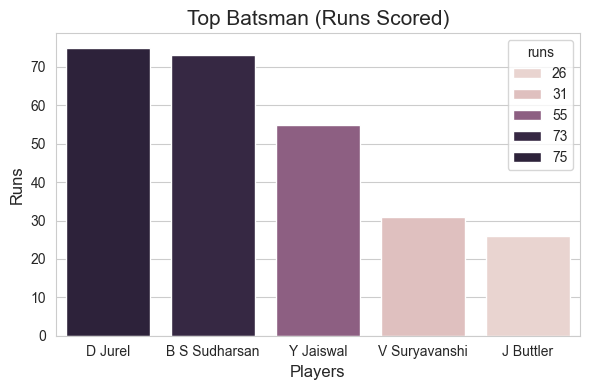

In [5]:
sns.set_style('whitegrid')
plt.figure(figsize=(6,4))
sns.set_palette('viridis')

sns.barplot(x='player',y='runs',data=top_batsman.head(),hue='runs')
plt.title('Top Batsman (Runs Scored)',fontsize=15)
plt.xlabel('Players',fontsize=12)
plt.ylabel('Runs',fontsize=12)
plt.tight_layout()
plt.show()

## 5)Top Bowlers Analysis

In [6]:
# Top boweler analysis
top_bowlers=df_bowling.sort_values(by='wickets',ascending=False)
print('Top Bowlers \n',top_bowlers[['bowler','team','wickets']].head())

Top Bowlers 
               bowler team  wickets
6       Ravi Bishnoi   RR        4
8      Kagiso Rabada   GT        2
1      Nandre Burger   RR        1
3   Tushar Deshpande   RR        1
10   Prasidh Krishna   GT        1


## --> Top bowlers Visualization

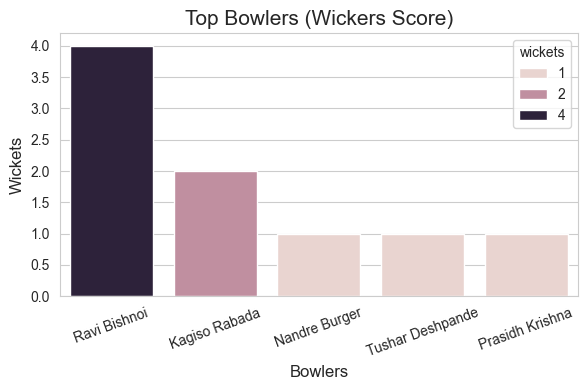

In [7]:
plt.figure(figsize=(6,4))
sns.set_style('whitegrid')

sns.barplot(x='bowler',y='wickets',data=top_bowlers.head(),hue='wickets')
plt.title('Top Bowlers (Wickers Score)',fontsize=15)
plt.xlabel('Bowlers',fontsize=12)
plt.ylabel('Wickets',fontsize=12)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 6) Team Performance by over

In [8]:
# Runs Per Over
team_performance=df_deliveries.groupby(['batting_team','over'])['total_runs'].sum().reset_index()
team_performance

## step 2 Cumulative SUM
team_performance['cumulative_runs']=team_performance.groupby('batting_team')['total_runs'].cumsum()

## -- Runs per Over Viaialization

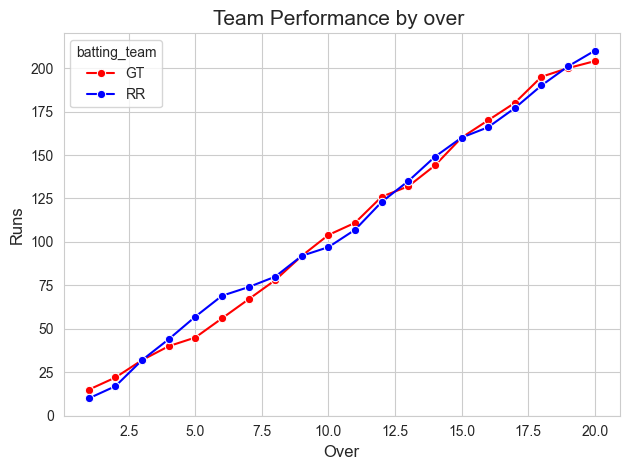

In [9]:
sns.set_style('whitegrid')
sns.lineplot(data=team_performance,x='over',y='cumulative_runs',hue='batting_team',palette=['r','b'],marker='o')
plt.title('Team Performance by over ',fontsize=15)
plt.xlabel('Over',fontsize=12)
plt.ylabel('Runs',fontsize=12)
plt.tight_layout()
plt.show()

## 8 ) over wise Runs 

In [10]:
## over wise runs 
over_wise_runs=df_deliveries.groupby(['batting_team','over'])['total_runs'].sum().reset_index()
#over_wise_runs


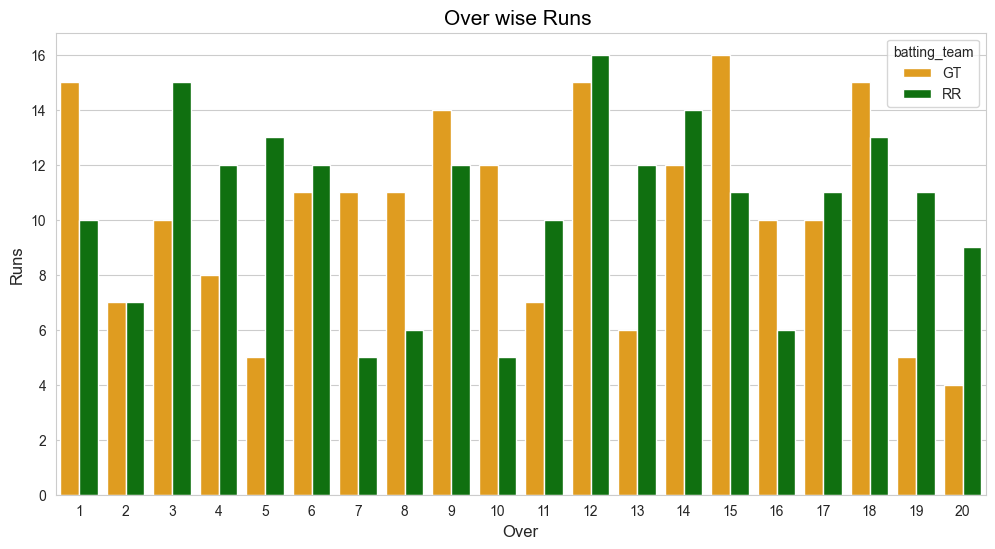

In [11]:
plt.figure(figsize=(12,6))
sns.barplot(data=over_wise_runs,x='over',y='total_runs',hue='batting_team',palette=['orange','g'])
plt.title('Over wise Runs ',fontsize=15,color='black')
plt.xlabel('Over',fontsize=12)
plt.ylabel('Runs',fontsize=12)
plt.show()

## 7) Match Phase Analysis (Power play / Death)

In [12]:
phase_runs=df_deliveries.groupby(['batting_team','match_phase'])['total_runs'].sum().reset_index()
rr_data=phase_runs[phase_runs['batting_team']=='RR']
print('RR_ Data\n',rr_data)

print('----------------------------------------------')

gt_data=phase_runs[phase_runs['batting_team']=='GT']
print('GT Phase Data \n',gt_data)

RR_ Data
   batting_team match_phase  total_runs
3           RR       Death          50
4           RR      Middle          91
5           RR  Power play          69
----------------------------------------------
GT Phase Data 
   batting_team match_phase  total_runs
0           GT       Death          44
1           GT      Middle         104
2           GT  Power play          56


### - Viasualazation

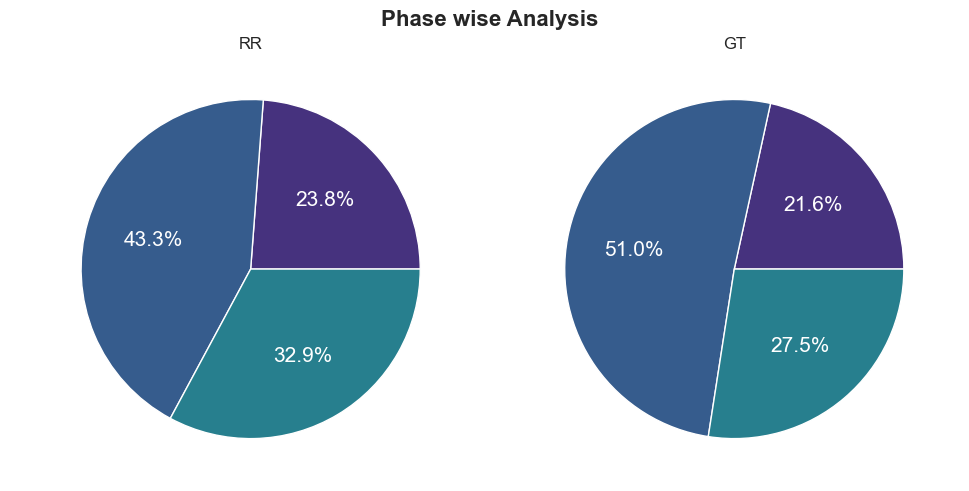

In [13]:
plt.figure(figsize=(10,5))
plt.suptitle('Phase wise Analysis',fontsize=16,fontweight='bold')
## RR
plt.subplot(1,2,1)
plt.pie(rr_data['total_runs'],labels=rr_data['match_phase'],autopct='%1.1f%%',
       textprops={'color':'white','fontsize':15})
plt.title('RR')

# GT
plt.subplot(1,2,2)
plt.pie(gt_data['total_runs'],labels=gt_data['match_phase'],autopct='%1.1f%%',
       textprops={'color':'white','fontsize':15})
plt.title('GT')
plt.tight_layout()
plt.show()

## Toss vs Match Result


In [14]:
toss_win=df_matches['toss_winner']==df_matches['winner']
print(toss_win.value_counts())

True    1
Name: count, dtype: int64


## Conclusion

This Exploratory Data Analysis (EDA) on the IPL dataset provides meaningful insights into team performance, player contributions, and match dynamics.
Both teams (RR and GT) showed competitive performance with closely matched total runs
Top batsmen played a crucial role in building the team’s score, indicating high dependency on key players
The middle overs contributed the highest runs, making it the most stable phase of the innings
Death overs were critical for accelerating the final score and often influenced match outcomes
Bowlers who performed well in the powerplay helped in gaining early advantage
The analysis also shows that winning the toss does not guarantee winning the match




## Final Insight:
Overall, consistent performance across all match phases—especially strong middle overs and aggressive death overs—plays a key role in determining the winning team. 
This project demonstrates how data analysis can be used to understand patterns and improve decision-making in sports.